# Notebook 05.3: New Baseline - Joint EfficientNet-B0 + DenseNet121 Ensemble + TTA

From-scratch notebook for cardiomegaly classification using a **single ensemble model** that combines:

- EfficientNet-B0
- DenseNet121

Both backbones are fine-tuned jointly on the `train_val` images. Their logits are averaged to produce the final cardiomegaly probability.

The defaults are intentionally conservative so the joint model fits on laptop-class hardware.

This version also reports validation metrics with and without TTA, and uses TTA for final test inference.

Scoring target:

`0.5 * AUROC + 0.25 * Sensitivity + 0.25 * Specificity`


---
## Step 1: Imports

In [26]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_B0_Weights,
    densenet121,
    efficientnet_b0,
)
from tqdm.auto import tqdm

print("Imports OK")


Imports OK


## Step 2: Reproducibility and device

In [27]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")


Device: mps


## Step 3: Configuration

In [28]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 320
BATCH_SIZE = 4
NUM_WORKERS = 0
VAL_FRAC = 0.2
EPOCHS = 6
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

TTA_SCALES = [IMG_SIZE, IMG_SIZE + 32, IMG_SIZE + 64]

print(f"IMG_SIZE     : {IMG_SIZE}  # bumped back up for this rerun")
print(f"BATCH_SIZE   : {BATCH_SIZE}  # conservative batch for the joint ensemble")
print(f"EPOCHS       : {EPOCHS}")
print(f"LR           : {LR}")
print(f"WEIGHT_DECAY : {WEIGHT_DECAY}")
print(f"TTA_SCALES   : {TTA_SCALES} x {2} views (orig + hflip)")


IMG_SIZE     : 320  # bumped back up for this rerun
BATCH_SIZE   : 4  # conservative batch for the joint ensemble
EPOCHS       : 6
LR           : 0.0001
WEIGHT_DECAY : 0.0001
TTA_SCALES   : [320, 352, 384] x 2 views (orig + hflip)


## Step 4: Load labels

In [29]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Patient Age": "age",
    "Patient Sex": "sex",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)

print(df.head())
print("\nFinding counts:")
print(df["finding"].value_counts())
print(f"\nPositive rate: {df['label'].mean():.3f}")
print(f"Total         : {len(df)}")


       image_file  age sex       finding  label
0  IMG_000838.png   65   F  Cardiomegaly      1
1  IMG_000239.png   76   F  Cardiomegaly      1
2  IMG_000217.png   61   M    No Finding      0
3  IMG_001193.png   52   F    No Finding      0
4  IMG_001097.png   35   F    No Finding      0

Finding counts:
finding
No Finding      858
Cardiomegaly    720
Name: count, dtype: int64

Positive rate: 0.456
Total         : 1578


## Step 5: Dataset

In [30]:
class CardiomegalyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def _load_image(self, fname):
        img = Image.open(self.img_dir / fname)
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_file"])
        if self.transform is not None:
            img = self.transform(img)
        if not self.return_label:
            return img, row["image_file"]
        return img, torch.tensor(row["label"], dtype=torch.float32)


## Step 6: Train / validation split

In [31]:
train_df, val_df = train_test_split(
    df,
    test_size=VAL_FRAC,
    stratify=df["label"],
    random_state=SEED,
)

print(f"Train: {len(train_df)}  (pos rate {train_df['label'].mean():.3f})")
print(f"Val  : {len(val_df)}  (pos rate {val_df['label'].mean():.3f})")


Train: 1262  (pos rate 0.456)
Val  : 316  (pos rate 0.456)


## Step 7: Transforms and loaders

In [32]:
def build_transform(img_size, augment=False):
    ops = [T.Resize((img_size, img_size))]
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=5),
            T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
            T.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    ops += [
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)

train_tf = build_transform(IMG_SIZE, augment=True)
val_tf = build_transform(IMG_SIZE, augment=False)

train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf)
val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")


Train batches: 316
Val   batches: 79


## Step 8: Metrics helpers

In [33]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold_score(y_true, y_prob):
    auroc = roc_auc_score(y_true, y_prob)
    best_thr = 0.5
    best_score = -1.0
    for thr in np.linspace(0.01, 0.99, 199):
        sens, spec = sens_spec(y_true, y_prob, threshold=thr)
        score = datathon_score(auroc, sens, spec)
        if score > best_score:
            best_thr = float(thr)
            best_score = float(score)
    return best_thr, best_score


def summarize_predictions(y_true, y_prob):
    auroc = roc_auc_score(y_true, y_prob)
    best_thr, best_score = best_threshold_score(y_true, y_prob)
    best_sens, best_spec = sens_spec(y_true, y_prob, threshold=best_thr)
    return {
        "auroc": float(auroc),
        "thr": float(best_thr),
        "sens": float(best_sens),
        "spec": float(best_spec),
        "score": float(best_score),
    }


## Step 9: Joint ensemble model

In [34]:
class EfficientDenseEnsemble(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        self.efnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        ef_in = self.efnet.classifier[1].in_features
        self.efnet.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(ef_in, 1))

        self.dnet = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        dn_in = self.dnet.classifier.in_features
        self.dnet.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(dn_in, 1))

    def forward(self, x):
        ef_logits = self.efnet(x).squeeze(1)
        dn_logits = self.dnet(x).squeeze(1)
        return (ef_logits + dn_logits) / 2.0

model = EfficientDenseEnsemble().to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.2f}%)")


Trainable: 10,963,710 / 10,963,710 (100.00%)


## Step 10: Train / eval helpers

In [35]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, ps = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ps.extend(probs.tolist())
    ys = np.array(ys)
    ps = np.array(ps)
    auroc = roc_auc_score(ys, ps)
    sens, spec = sens_spec(ys, ps, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": ys, "p": ps}


@torch.no_grad()
def predict_probs_tta(model, loader, device, tta_scales=None, with_labels=True):
    model.eval()
    ys, names, probs_out = [], [], []
    for batch in loader:
        if with_labels:
            imgs, labels = batch
            ys.extend(labels.numpy().tolist())
        else:
            imgs, batch_names = batch
            names.extend(batch_names)
        imgs = imgs.to(device)
        scales = tta_scales if tta_scales else [imgs.shape[-1]]
        prob_sum = torch.zeros(imgs.size(0), device=device)
        n_views = 0
        for s in scales:
            if s == imgs.shape[-1]:
                view = imgs
            else:
                view = torch.nn.functional.interpolate(
                    imgs, size=(s, s), mode="bilinear", align_corners=False
                )
            prob_sum = prob_sum + torch.sigmoid(model(view))
            n_views += 1
            prob_sum = prob_sum + torch.sigmoid(model(torch.flip(view, dims=[3])))
            n_views += 1
        probs_out.extend((prob_sum / n_views).detach().cpu().numpy().tolist())
    if with_labels:
        return np.array(ys), np.array(probs_out)
    return names, np.array(probs_out)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_description(f"loss {loss.item():.3f}")
    return total / len(loader)

def train(model, train_loader, val_loader, optimizer, scheduler, epochs, device, tag="ensemble"):
    pos_weight = torch.tensor(
        [train_df["label"].eq(0).sum() / train_df["label"].eq(1).sum()],
        dtype=torch.float32,
        device=device,
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best = {"score": -1.0, "state": None, "epoch": 0}
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val = evaluate(model, val_loader, device)
        thr, tuned_score = best_threshold_score(val["y"], val["p"])
        sens_t, spec_t = sens_spec(val["y"], val["p"], threshold=thr)
        dt = time.time() - t0
        history.append({
            "epoch": epoch,
            "loss": tr_loss,
            "auroc": val["auroc"],
            "sens": sens_t,
            "spec": spec_t,
            "thr": thr,
            "score": tuned_score,
        })
        star = ""
        if tuned_score > best["score"]:
            best = {
                "score": tuned_score,
                "auroc": val["auroc"],
                "sens": sens_t,
                "spec": spec_t,
                "thr": thr,
                "state": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
            }
            star = " ★"
            torch.save(model.state_dict(), CKPT_DIR / f"{tag}_best.pt")
        scheduler.step()
        print(
            f"[{tag}] ep {epoch:02d}/{epochs}  loss {tr_loss:.4f}  "
            f"AUROC {val['auroc']:.4f}  sens {sens_t:.3f}  spec {spec_t:.3f}  "
            f"score {tuned_score:.4f}  thr {thr:.3f}  ({dt:.1f}s){star}"
        )
    model.load_state_dict(best["state"])
    return model, pd.DataFrame(history), best


## Step 11: Train the ensemble

In [36]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

model, history_df, best = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs=EPOCHS,
    device=device,
    tag="efnet_densenet_joint_ensemble",
)

print("\nBest checkpoint:")
print(best)


[efnet_densenet_joint_ensemble] ep 01/6  loss 0.6548  AUROC 0.8898  sens 0.833  spec 0.779  score 0.8480  thr 0.510  (150.9s) ★


[efnet_densenet_joint_ensemble] ep 02/6  loss 0.5387  AUROC 0.9221  sens 0.882  spec 0.791  score 0.8792  thr 0.287  (135.9s) ★


[efnet_densenet_joint_ensemble] ep 03/6  loss 0.4943  AUROC 0.9334  sens 0.854  spec 0.866  score 0.8968  thr 0.421  (132.6s) ★


[efnet_densenet_joint_ensemble] ep 04/6  loss 0.4172  AUROC 0.9384  sens 0.875  spec 0.843  score 0.8987  thr 0.446  (137.4s) ★


[efnet_densenet_joint_ensemble] ep 05/6  loss 0.3563  AUROC 0.9399  sens 0.840  spec 0.901  score 0.9053  thr 0.703  (134.7s) ★


[efnet_densenet_joint_ensemble] ep 06/6  loss 0.3118  AUROC 0.9436  sens 0.861  spec 0.884  score 0.9080  thr 0.604  (138.7s) ★

Best checkpoint:
{'score': 0.9079861111111112, 'auroc': 0.9435562015503877, 'sens': 0.8611111111111112, 'spec': 0.8837209302325582, 'thr': 0.6039393939393939, 'state': OrderedDict([('efnet.features.0.0.weight', tensor([[[[ 1.2264e-01,  6.5662e-01,  4.5690e-01],
          [-1.0984e-01, -6.0979e-01, -3.3322e-01],
          [ 2.9108e-02, -1.0306e-01, -1.0297e-01]],

         [[ 6.4609e-02,  1.6554e+00,  1.7438e+00],
          [-1.3540e-01, -1.5364e+00, -1.5934e+00],
          [ 5.1317e-02, -1.1354e-01, -1.2573e-01]],

         [[ 8.8298e-02,  3.6153e-01,  2.6965e-01],
          [-1.1864e-01, -2.8096e-01, -2.1861e-01],
          [ 3.7739e-02, -7.0691e-02, -8.1648e-02]]],


        [[[ 1.6642e-01, -1.9855e-01,  8.4837e-02],
          [ 8.9175e-01, -1.2093e+00,  2.7768e-01],
          [ 1.0755e+00, -1.2588e+00,  2.0791e-01]],

         [[ 3.3009e-01, -4.3263e-01,  

## Step 12: Plot training history

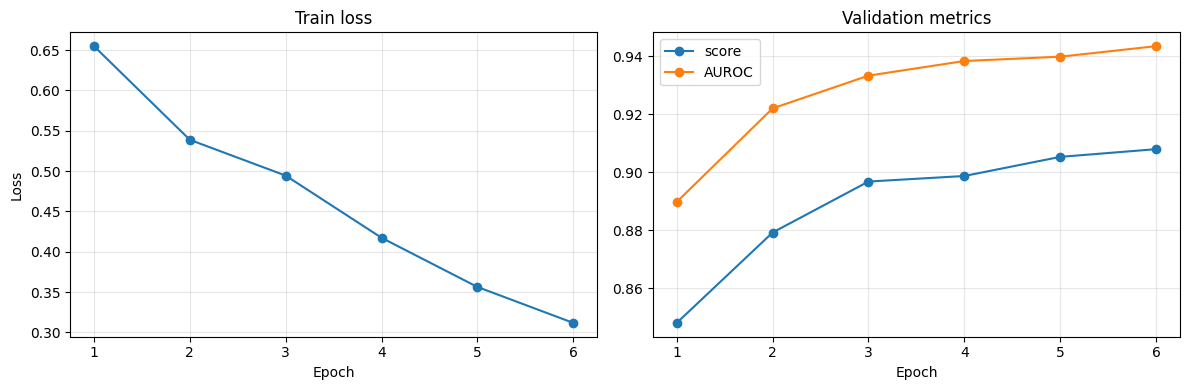

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["loss"], marker="o")
axes[0].set_title("Train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["score"], marker="o", label="score")
axes[1].plot(history_df["epoch"], history_df["auroc"], marker="o", label="AUROC")
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 13: Validation metrics (single-pass and TTA)


       mode    auroc      thr     sens     spec    score
single_pass 0.943556 0.603939 0.861111 0.883721 0.907986
        tta 0.939963 0.519798 0.902778 0.854651 0.909339


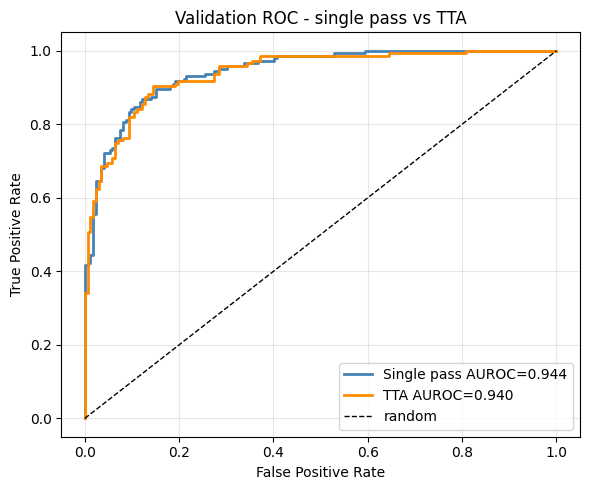

In [38]:
val_single = evaluate(model, val_loader, device)
single_metrics = summarize_predictions(val_single["y"], val_single["p"])

y_val_tta, val_probs_tta = predict_probs_tta(model, val_loader, device, tta_scales=TTA_SCALES, with_labels=True)
tta_metrics = summarize_predictions(y_val_tta, val_probs_tta)

metrics_df = pd.DataFrame([
    {"mode": "single_pass", **single_metrics},
    {"mode": "tta", **tta_metrics},
])
print(metrics_df.to_string(index=False))

best_thr = tta_metrics["thr"]

fig, ax = plt.subplots(figsize=(6, 5))
for name, probs, color in [
    (f"Single pass AUROC={single_metrics['auroc']:.3f}", val_single["p"], "steelblue"),
    (f"TTA AUROC={tta_metrics['auroc']:.3f}", val_probs_tta, "darkorange"),
]:
    fpr, tpr, _ = roc_curve(val_single["y"], probs)
    ax.plot(fpr, tpr, lw=2, label=name, color=color)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Validation ROC - single pass vs TTA")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 14: Submission CSV with TTA


In [39]:
test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
print(f"Test images: {len(test_files)}")

test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

all_names, all_probs = predict_probs_tta(model, test_loader, device, tta_scales=TTA_SCALES, with_labels=False)

sub = pd.DataFrame({
    "image_file": all_names,
    "prob": all_probs,
})
sub["pred"] = (sub["prob"] >= best_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_05_3_joint_efnet_densenet_tta_{stamp}.csv"
sub.to_csv(out_path, index=False)

print(f"\nWrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")


Test images: 176

Wrote /Users/jasonsmith/Desktop/medical-cv-hackathon/outputs/predictions/submission_05_3_joint_efnet_densenet_tta_20260421_1350.csv
       image_file      prob  pred
0  IMG_000018.png  0.944353     1
1  IMG_000021.png  0.074335     0
2  IMG_000039.png  0.621947     1
3  IMG_000044.png  0.232339     0
4  IMG_000047.png  0.508597     0

Positive rate in submission: 0.460
